(14500,)
(14500,)
(14500,)
(14500,)
(14500,)
(14500,)


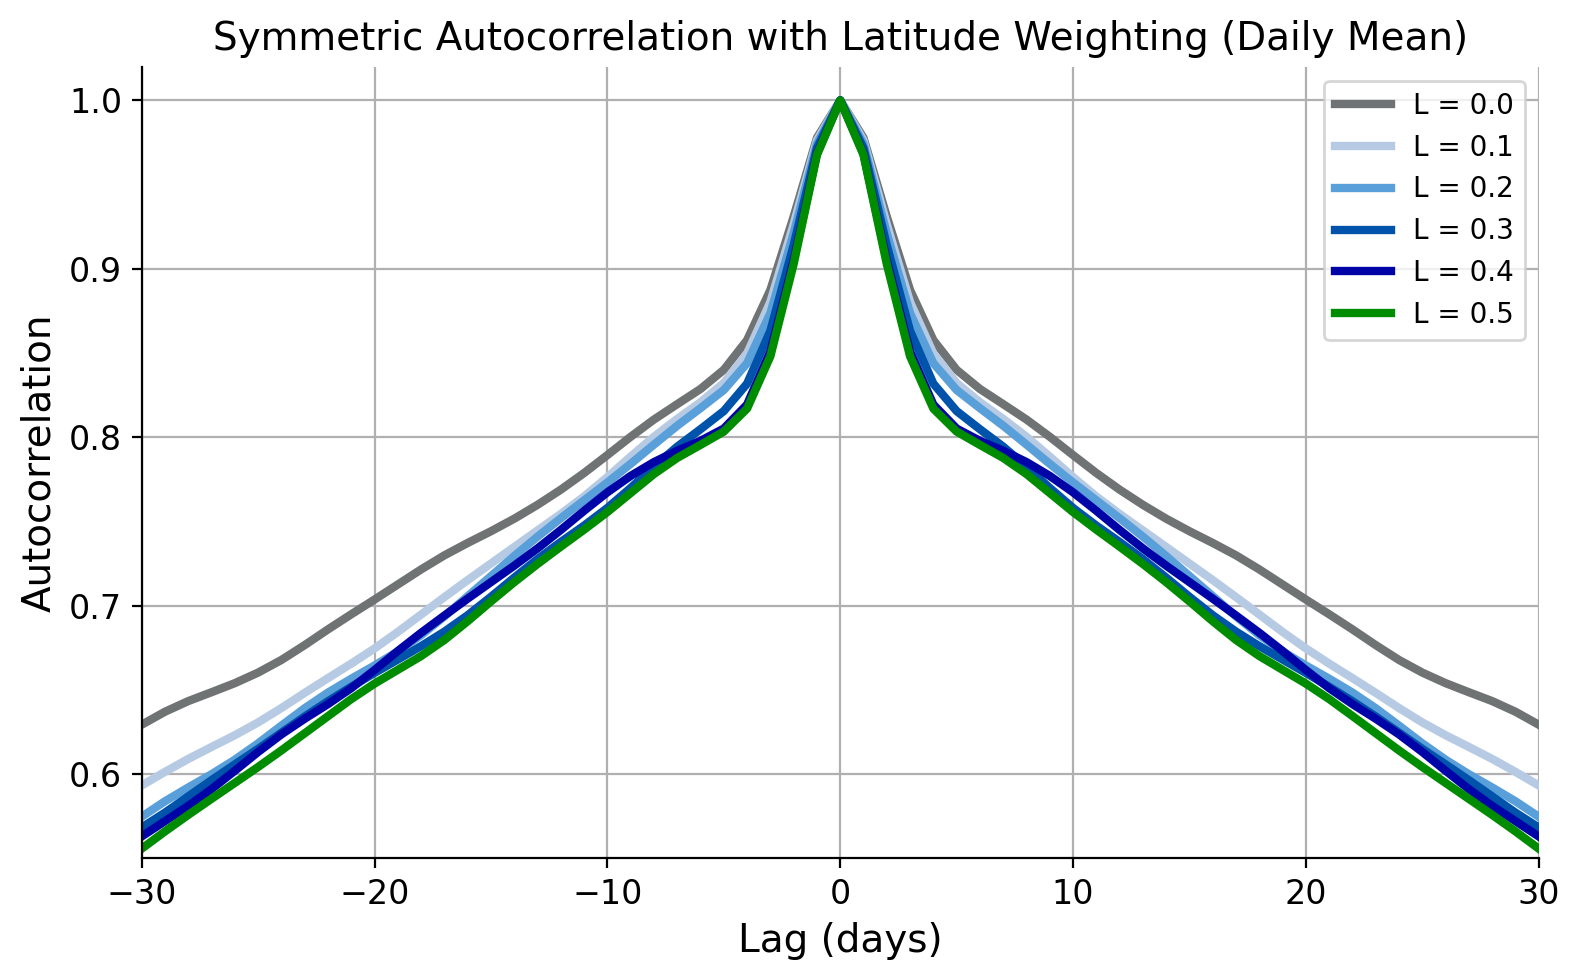

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)

        return EOF_modes, PCs_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)


# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
auto_length = 100
window_length = 500
split_to_chunk = False
latitudes = np.linspace(0, 90, 32)

# Load data, calculate daily mean, and compute PC1 for all PR values
PC1_all  = []
EOFs_all = []


for PR in PR_values:
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    variable_name = "u"
    u_data = moist_dycore.load_data(file_path, variable_name)
    
    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    # Use the custom EOF class
    EOFs, PC_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[5000:, 32:], latitudes, n_components=32, field="1D")
    EOFs_all.append(EOFs[:])  # Extract normalized PC1 for the current PR value
    PC1_all.append(PC_normalized[:])  # Extract normalized PC1 for the current PR value
    print(PC_normalized[:].shape)
    
    

PC1_all  = np.array(PC1_all)
EOFs_all = np.array(EOFs_all)


# Calculate symmetric autocorrelation for PC1
autocorr_results = []
for i in range(len(PR_values)):
    autocorr_results.append(
        moist_dycore.symmetric_autocorr(PC1_all[i, :], auto_length, split_to_chunk, window_length)
    )

# tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [5]:
start_day = 500+5000
end_day   = 20000

day_length = len(np.arange(start_day, end_day))
print(day_length)
print(f"start_day = {start_day}, end_day = {end_day}, total day = {day_length}")

Uzm_all = np.zeros((6, day_length, 64))
# num_days = Uzm_6hourly_all.shape[0] // 4  # Ensure divisible by 4
a = 0
for PR in [0,10,20,30,40,50]:
    with h5py.File(f"/data92/PeterChang/1120_preprocessing//PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5") as f:
        day = f["u"][int((start_day-500)*4):,:].shape[0]
        Uzm_all[a] = f["u"][int(start_day-500)*4:,:].reshape(int(day/4),4,64).mean(axis=1)
        
    a += 1

14500
start_day = 5500, end_day = 20000, total day = 14500


In [6]:
EMF = np.zeros((6, day_length, 64))
aa = 0
for PR in range(0, 60, 10):
        EMF_file = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/EMF_add_time_dim/EMF_climatology_add_time_dim.h5"
        with h5py.File(EMF_file,'r') as f :
            EMF[aa] = f["EMF"][int(start_day-500)*4:,:].reshape(int(day/4),4,64).mean(axis=1)
        aa += 1

In [7]:
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy **2

sigma_onlyz = np.linspace(0,1,20)
yy, sigma_mean2 = np.meshgrid(y, sigma_onlyz)

dmdy = np.zeros((6, day_length, 64))
for a in range(6):
    Mzm = EMF[a] # EMF_oringin_grid[a]
    print(Mzm.shape)
    
    for i in range(1,64-1):
        dmdy[a,:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    # dmdy[a,:,:,1:-1] = -((Mzm[:,:,2:] - Mzm[:,:,:-2]) * cy2[1:-1]) / (radius * (cy2[1:-1]) * (yd[2:] - yd[:-2]))
    
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))
print(dmdy.shape)



(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(14500, 64)
(6, 14500, 64)


In [8]:
prec_daily_all = np.zeros((6,day_length,16))
aa = 0
for PR in range(0,60,10):
    with h5py.File(f"/data92/PeterChang/1120_preprocessing/PR{PR}/variability/prec/prec_PR{PR}.h5"
    ) as f:
        prec = f["prec"][int(start_day-500)*4:, 32-8:32+8] #(time, y)
                
    num_days = prec.shape[0] // 4  # Ensure divisible by 4
    prec_daily_all[aa] = prec[:num_days * 4].reshape(num_days, 4, *prec.shape[1:]).mean(axis=1)
    aa += 1

Text(0.5, 0, 'Latitude')

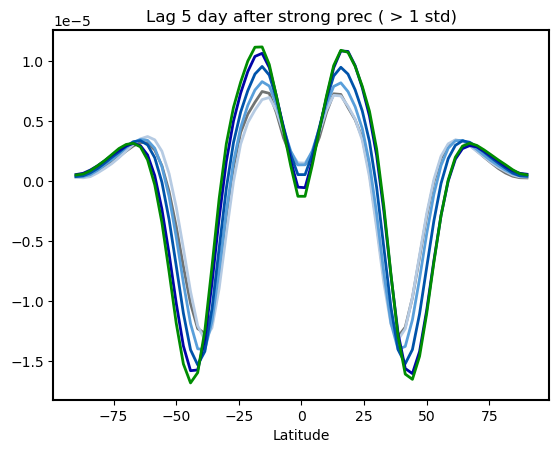

In [9]:
prec_daily_all_mean = prec_daily_all.mean(axis=2)
plt.figure()
aa  = 0
for i in range(6):
    time_idx = np.where(prec_daily_all_mean[aa] > prec_daily_all_mean[aa].mean() + prec_daily_all_mean[aa].std())
    time_idx_lag = np.asarray(time_idx) + 5
    time_idx_lag = time_idx_lag[time_idx_lag < dmdy.shape[1] - 5]
    plt.plot(y, dmdy[aa, time_idx_lag].mean() - dmdy[aa].mean(axis=0), color=colors[i], lw=2)
    
    aa += 1

plt.title("Lag 5 day after strong prec ( > 1 std)")
plt.xlabel("Latitude")

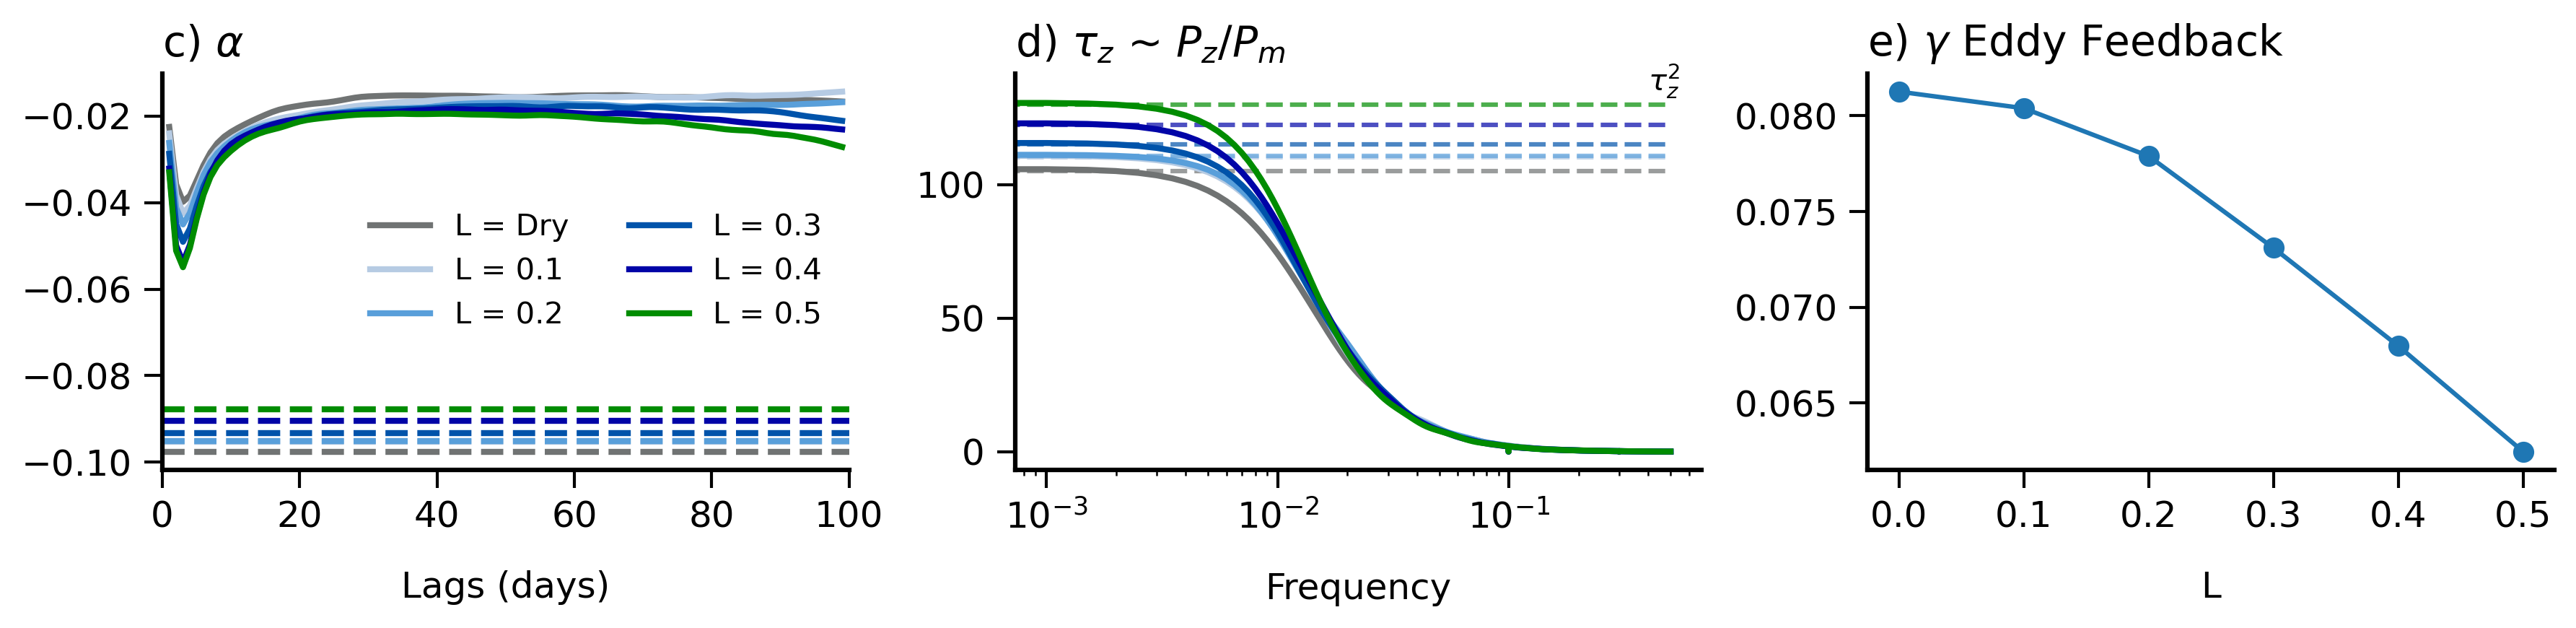

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

# Parameters
num_exp = 6
num_lat = 32
lg = 2000  # Length of the interval
overlap = 1000  # Overlap between windows
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

# Placeholder for results
tau_z_square = np.zeros(num_exp)
m_fig3 = np.zeros((num_exp, day_length))
PP_all_u = np.zeros((num_exp, day_length))
total_L = np.zeros((num_exp, 100))
total_L_final = np.zeros(num_exp)
fig4_final = np.zeros(num_exp)
take_min_day = 90  #40
take_max_day = 100 #60
take_len_day = take_max_day - take_min_day

# Helper functions
def compute_running_mean(data, window_size):
    """Compute running mean for smoothing."""
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window_size:] - cumsum[:-window_size]) / float(window_size)

def compute_fft_cross_spectrum(signal1, signal2, lg, overlap):
    """Compute FFT-based cross-spectrum for two signals."""
    Pz_all = np.zeros(lg, dtype=np.complex_)
    Pm_all = np.zeros(lg, dtype=np.complex_)
    n_segments = 0

    for i in range(0, len(signal1) - lg + 1, lg - overlap):
        hanning_window = np.hanning(lg)
        Z_segment = fft(signal1[i:i + lg] * hanning_window) / len(hanning_window)
        M_segment = fft(signal2[i:i + lg] * hanning_window) / len(hanning_window)

        Pz_all += Z_segment * np.conjugate(Z_segment)
        Pm_all += M_segment * np.conjugate(M_segment)
        n_segments += 1

    return Pz_all / n_segments, Pm_all / n_segments

# Generate `m_fig3` and `PP_all_u`
for exp_idx in range(num_exp):
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    PP_all_u[exp_idx] = single_EOF_u.PC[0]
    EOF_u_final = single_EOF_u.EOF[0]
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)

# Plot initialization
# fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
fig, ax = plt.subplots(1,3, figsize=(12,3), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5

# Compute cross-spectrum and plot for each experiment
for exp_idx in range(num_exp):
    Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
    freq = np.fft.fftfreq(lg)
    spectrum = Pz_all / Pm_all / (86400**2)

    # Smooth spectrum for better visualization
    tau_smoothed = compute_running_mean(spectrum.real, 5)
    freq_smoothed = compute_running_mean(freq, 5)
    spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
    sorted_idx = np.argsort(freq_smoothed)

    # Plot smoothed spectrum
    ax[1].plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
               label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

    # Compute and plot tau_z_square
    tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
    ax[1].hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
                 xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)

# Compute logarithmic derivative for Fig. 3(a)
for exp_idx in range(num_exp):
    autocorr_data = autocorr_results[exp_idx]  # Use the provided autocorrelation results in Fig.1
    for i in range(1, 100):
        total_L[exp_idx, i] = np.log(autocorr_data[100 + i]) / i

    total_L_final[exp_idx] = np.mean(total_L[exp_idx, take_min_day:take_max_day])

    if exp_idx == 0:
        ax[0].plot(range(1, 100), total_L[exp_idx, 1:], label=f"L = Dry", color=colors[exp_idx], lw=2)
    else:
        ax[0].plot(range(1, 100), total_L[exp_idx, 1:], label=f"L = {exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)
    
    ax[0].axhline(-1 / (tau_z_square[exp_idx] ** 0.5), linestyle="--", color=colors[exp_idx], lw=2)

# Calculate feedback differences for Fig. 3(c)
for exp_idx in range(num_exp):
    fig4_final[exp_idx] = np.median(total_L[exp_idx, take_min_day:take_max_day]) - (-1 / tau_z_square[exp_idx]**0.5)

# Plot feedback differences
L_values = np.arange(0, 0.6, 0.1)
ax[2].scatter(L_values, fig4_final)
ax[2].plot(L_values, fig4_final)

# Final plot customizations
ax[0].set_title(r"c) $\alpha$", loc="left", fontsize=14)
# ax[0].set_title(r"a) $\alpha$ and $-1/\tau_z$", loc="left", fontsize=14)
ax[0].set_xlabel("Lags (days)", fontsize=12 , labelpad=12)
ax[0].set_xlim([0, 100])
ax[0].legend(loc = 0, prop={'size': 10},frameon=False, ncols=2)

ax[1].set_title(r"d) $\tau_z$ ~ $P_z / P_m$", loc="left", fontsize=14)
ax[1].set_xlabel("Frequency", fontsize=12 , labelpad=12)
ax[1].text(0.4, 135, r"$\tau ^2 _{z}$")
ax[1].set_xscale("log")

ax[2].set_title(r"e) $\gamma$ Eddy Feedback", loc="left", fontsize=14)
ax[2].set_xlabel("L", fontsize=12 , labelpad=12)

for i in range(3):
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].tick_params(axis='x', labelsize=12, pad=4)
    ax[i].tick_params(axis='y', labelsize=12, pad=4)
    ax[i].tick_params(direction='out', length=6, width=1)

plt.tight_layout()
plt.show()

In [342]:
# Statistical test

# Set the maximum lag
max_lag = 100
num_exp = 6   # Number of experiments
num_samples = 500  # Number of samples

# 1. Compute the autocorrelation for original PC1_all
auto_record = np.zeros((num_exp, max_lag + 1))  # (num_exp, max_lag)
auto_record[:, 0] = 1  # ACF(0) = 1
residual = np.zeros_like(auto_record)

for lag in range(1, max_lag + 1):
    for exp in range(num_exp):
        # Compute autocorrelation at lag `lag`
        auto_record[exp, lag] = np.corrcoef(PC1_all[exp, :-lag], PC1_all[exp, lag:])[0, 1]
        # Compute residual standard deviation
        residual[exp, lag] = np.std(auto_record[exp, lag] * PC1_all[exp, :-lag] - PC1_all[exp, lag:])



# 2. Generate AR process simulated time series
AR_ensemble = np.zeros((num_exp, max_lag + 1, num_samples, PC1_all.shape[1]))  # (exp, lag, samples, time)

for exp in range(num_exp):  # Iterate over each experiment
    for t in range(1, AR_ensemble.shape[3]):  # Time steps
        for lag in range(1, max_lag + 1):  # Lag values
            AR_ensemble[exp, lag, :, t] = (
                auto_record[exp, lag] * AR_ensemble[exp, lag, :, t-1] +
                np.random.normal(0, scale=residual[exp, lag], size=num_samples)
            )
# 3. Compute the autocorrelation of AR process simulations
auto_record_exp = np.zeros((num_exp, max_lag + 1, num_samples))

for exp in range(num_exp):
    for lag in range(1, max_lag + 1):
        for ens in range(num_samples):
            auto_record_exp[exp, lag, ens] = np.corrcoef(
                AR_ensemble[exp, lag, ens, :-1], AR_ensemble[exp, lag, ens, 1:]
            )[0, 1]

# 4. Plot the boxplot of autocorrelation for different lags
plt.figure(figsize=(9, 5), dpi=300.)
lags = np.arange(1, max_lag + 1)
for i in [0,5]:
    plt.boxplot(auto_record_exp[i, 1:max_lag+1].T, positions=lags, widths=0.8, sym='')  # Ensure boxplot is correctly aligned
    plt.plot(autocorr_results[i,100:], label=f"L = {PR * 0.01}", color=colors[i], lw=2)


# Customize plot
plt.xticks(np.linspace(0, max_lag, 11), labels=np.linspace(0, max_lag, 11, dtype=int))
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Boxplot of Autocorrelation for Different Lags")
plt.grid()
plt.xlim([0,30])
plt.ylim([0.52,1.02])
plt.show()

In [380]:
import sys
sys.path.append("/data92/PeterChang/") 
from atmospheric_analysis import ARStatisticalTest  

In [385]:
# Assuming PC1_all is already defined and has shape (6, time)
ar_test = ARStatisticalTest(PC1_all, max_lag=100, num_samples=500)

# Run the statistical test
auto_record_exp = ar_test.run_test()

# Plot the results for the first experiment
# ar_test.plot_results(auto_record_exp, exp_index=0)

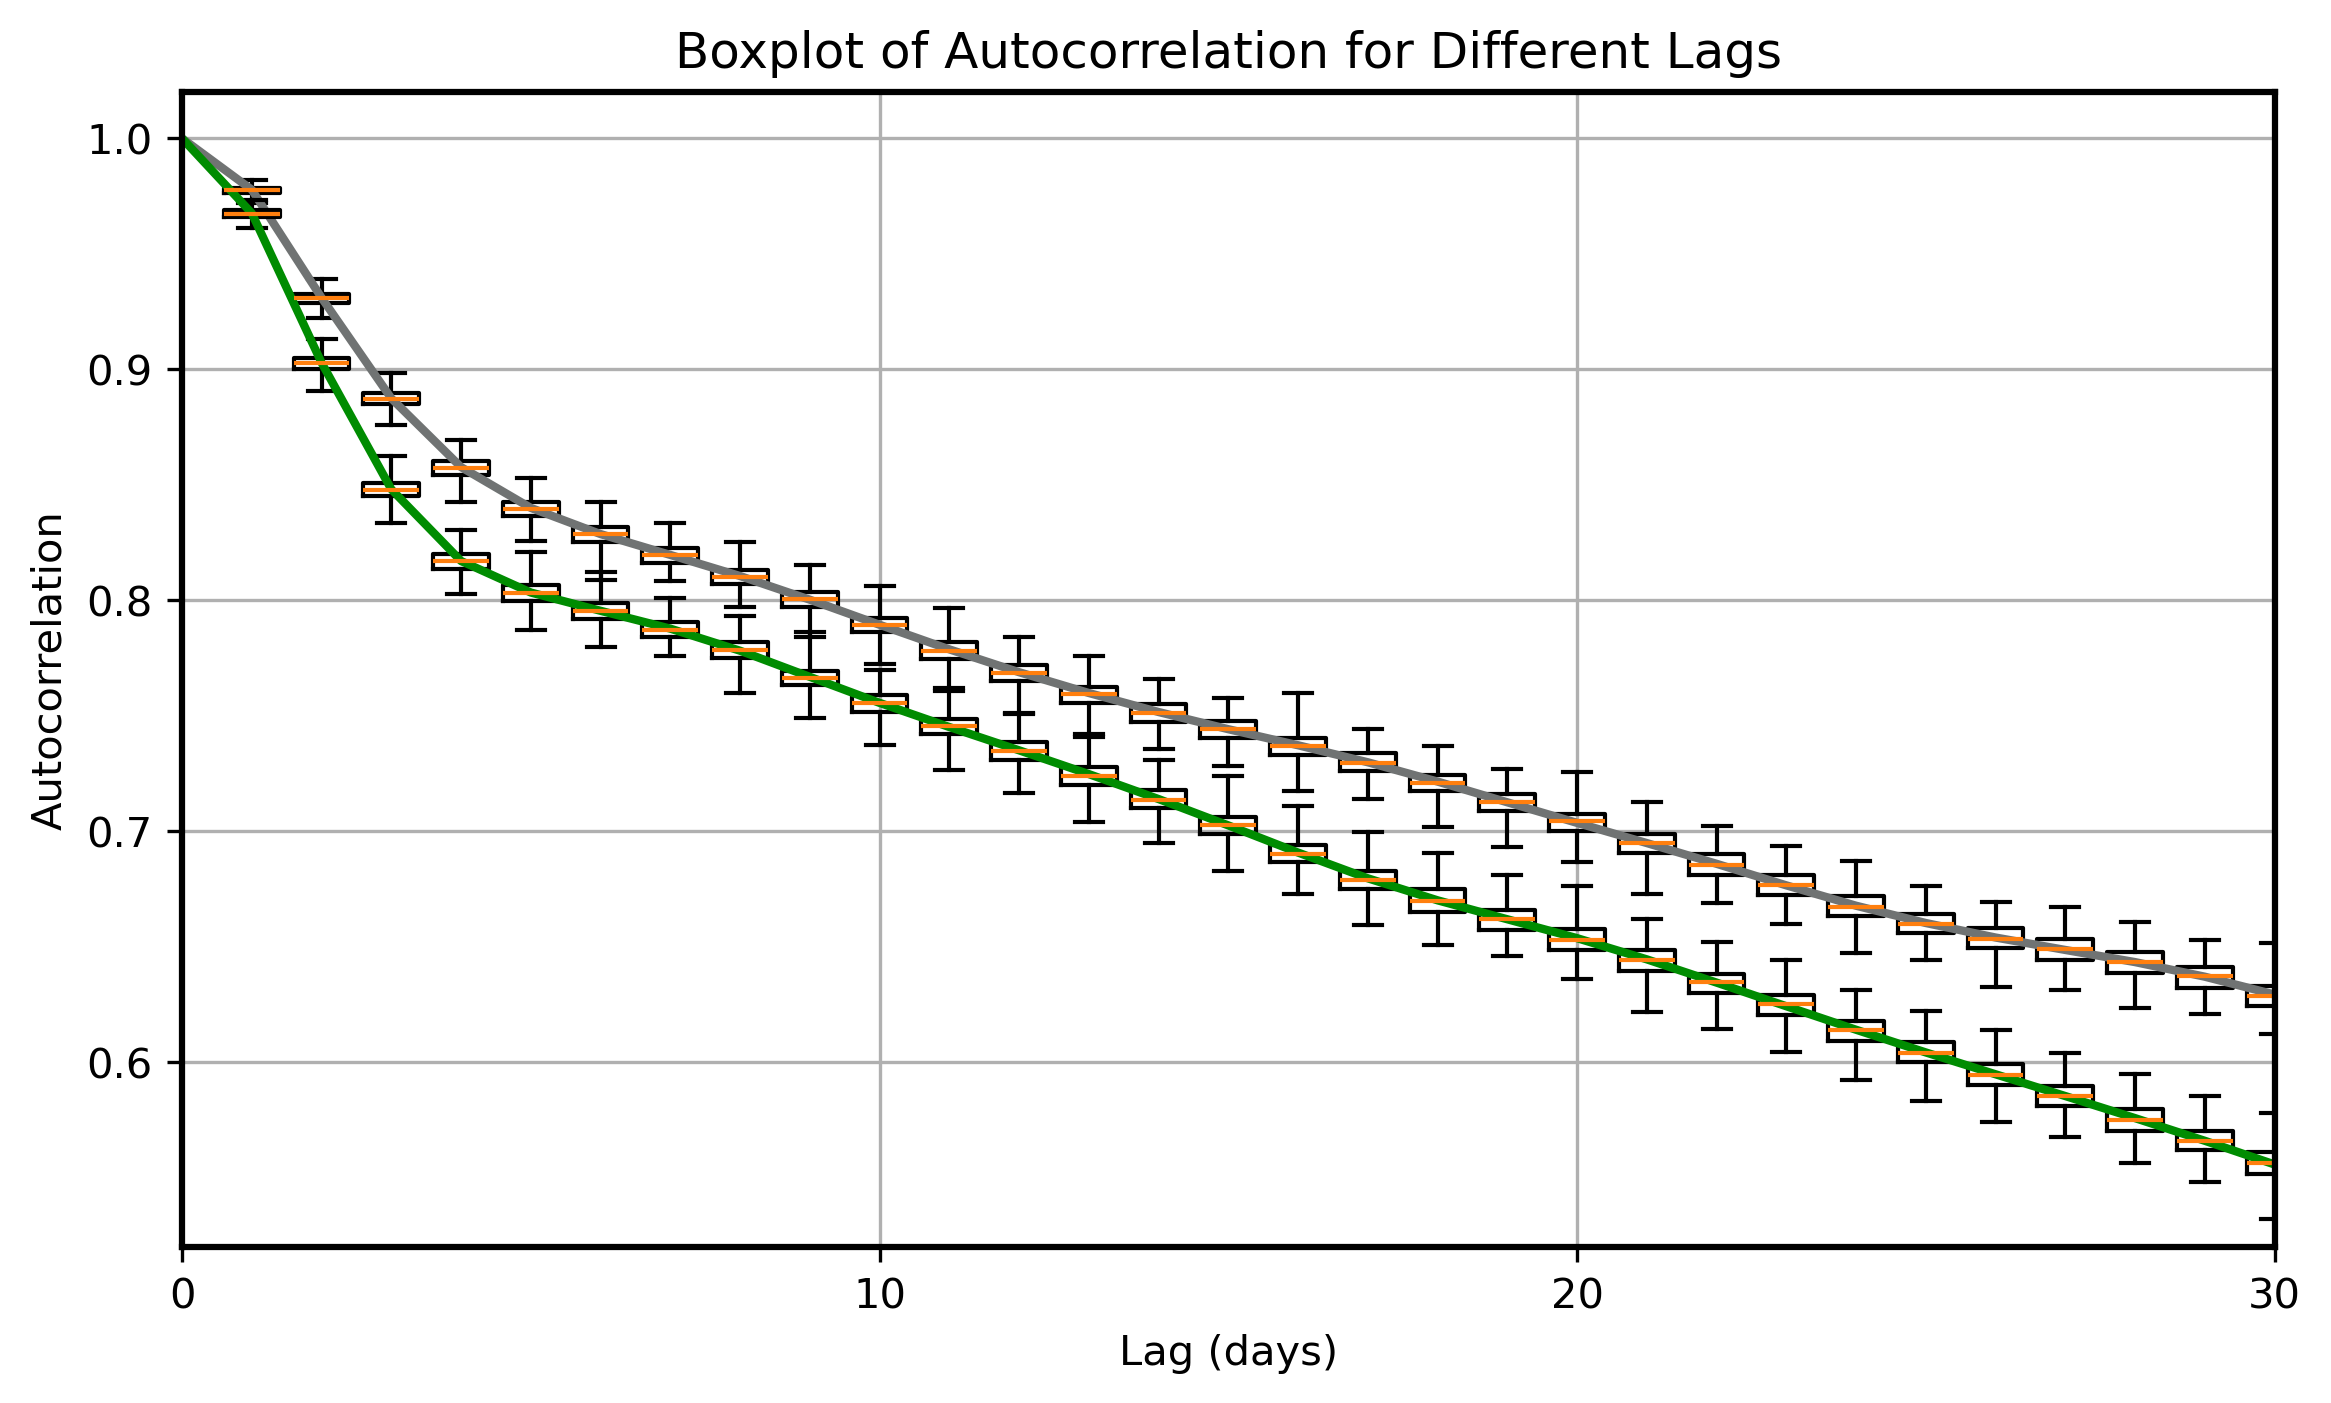

In [601]:
# 4. Plot the boxplot of autocorrelation for different lags
plt.figure(figsize=(9, 5), dpi=300.)
lags = np.arange(1, max_lag + 1)
for i in [0,5]:
    plt.boxplot(auto_record_exp[i, 1:max_lag+1].T, positions=lags, widths=0.8, sym='', whis=[0, 100])  # Ensure boxplot is correctly aligned
    plt.plot(autocorr_results[i,100:], label=f"L = {PR * 0.01}", color=colors[i], lw=2)


# Customize plot
plt.xticks(np.linspace(0, max_lag, 11), labels=np.linspace(0, max_lag, 11, dtype=int))
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Boxplot of Autocorrelation for Different Lags")
plt.grid()
plt.xlim([0,30])
plt.ylim([0.52,1.02])
plt.show()

# Calculating tau_z statistical test

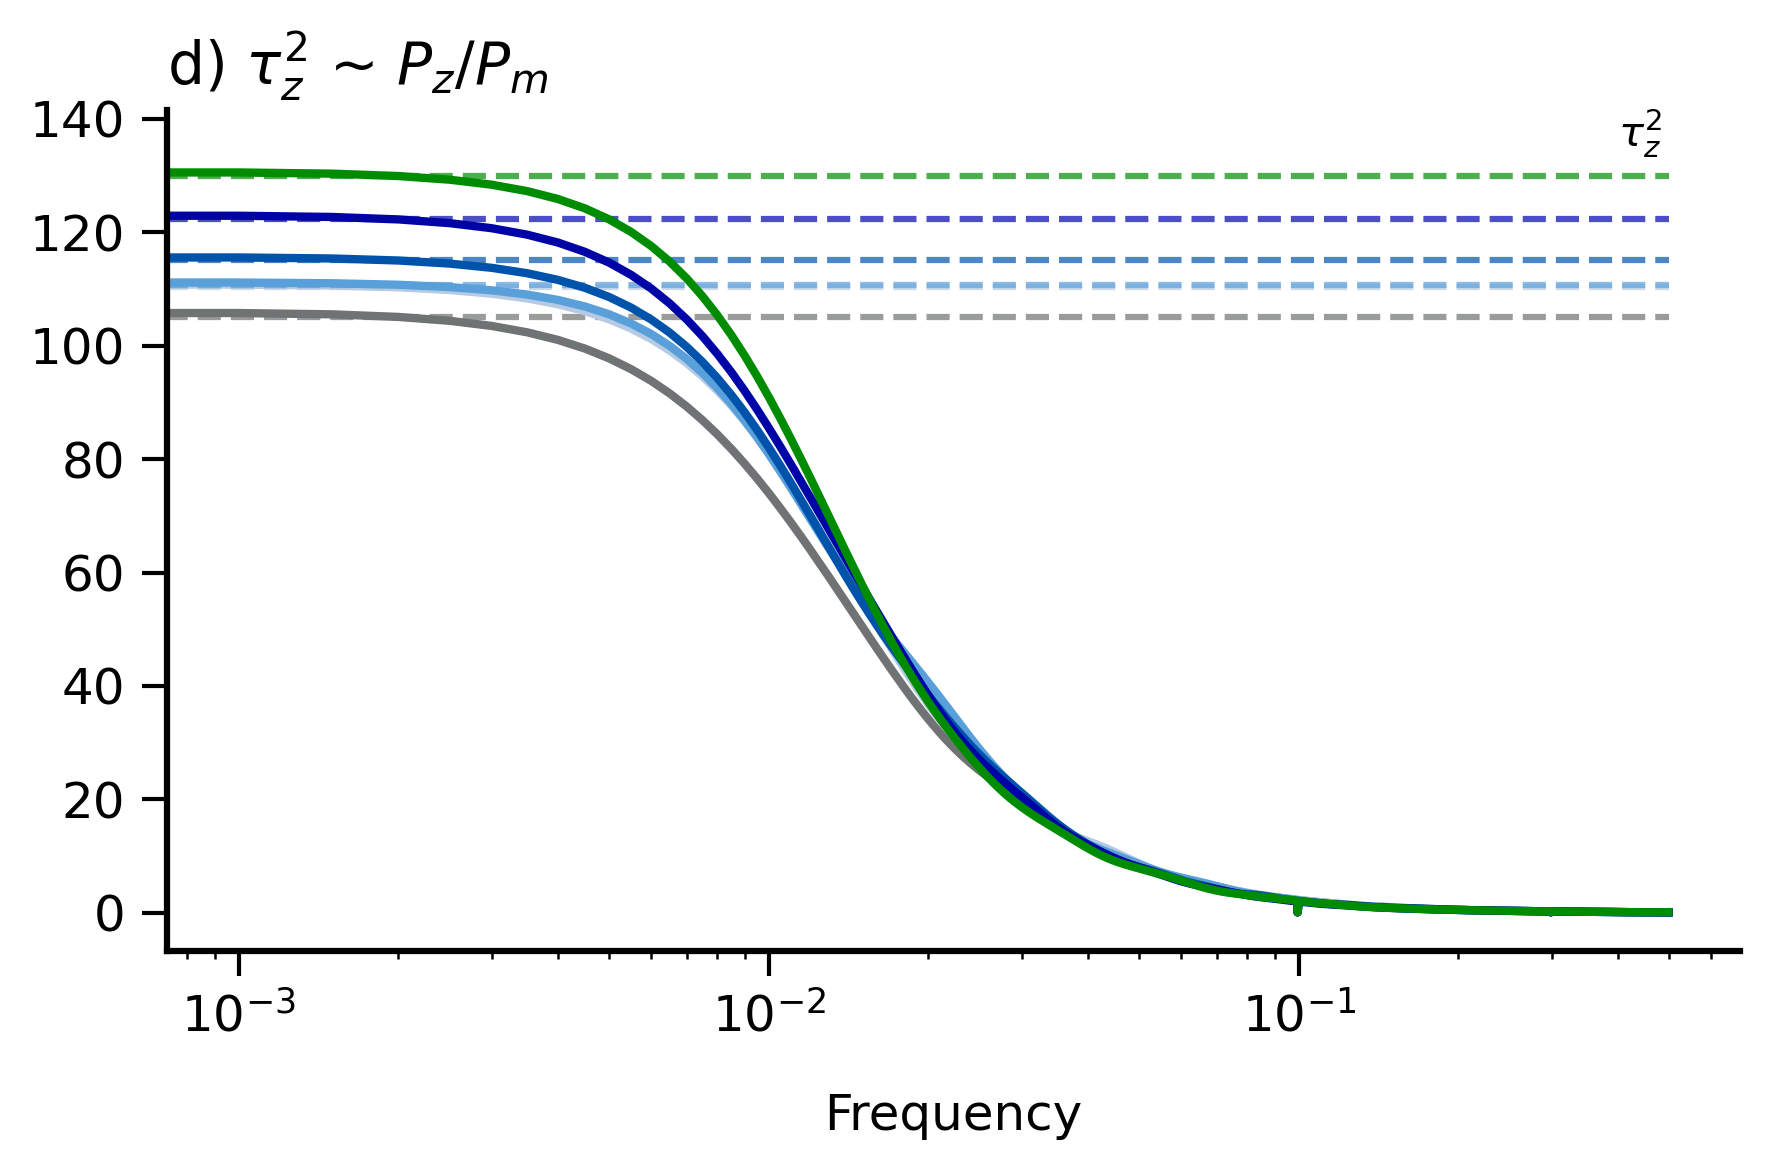

In [388]:
sigma_fixed = 0.5  # standard deviation
residuals = np.random.normal(loc=0, scale=sigma_fixed, size=len(Pz_all))


# Generate `m_fig3` and `PP_all_u`
for exp_idx in range(num_exp):
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    PP_all_u[exp_idx] = single_EOF_u.PC[0]
    EOF_u_final = single_EOF_u.EOF[0]
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)

# Plot initialization
# fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5

# Compute cross-spectrum and plot for each experiment
for exp_idx in range(num_exp):
    Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
    freq = np.fft.fftfreq(lg)
    spectrum = Pz_all / Pm_all / (86400**2)

    # Smooth spectrum for better visualization
    tau_smoothed = compute_running_mean(spectrum.real, 5)
    freq_smoothed = compute_running_mean(freq, 5)
    spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
    sorted_idx = np.argsort(freq_smoothed)

    # Plot smoothed spectrum
    plt.plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
               label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

    # Compute and plot tau_z_square
    tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
    plt.hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
                 xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)

plt.title(r"d) $\tau_z^2$ ~ $P_z / P_m$", loc="left", fontsize=14)
plt.xlabel("Frequency", fontsize=12 , labelpad=12)
plt.text(0.4, 135, r"$\tau ^2 _{z}$")
plt.xscale("log")

for i in range(1):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis='x', labelsize=12, pad=4)
    ax.tick_params(axis='y', labelsize=12, pad=4)
    ax.tick_params(direction='out', length=6, width=1)

plt.tight_layout()

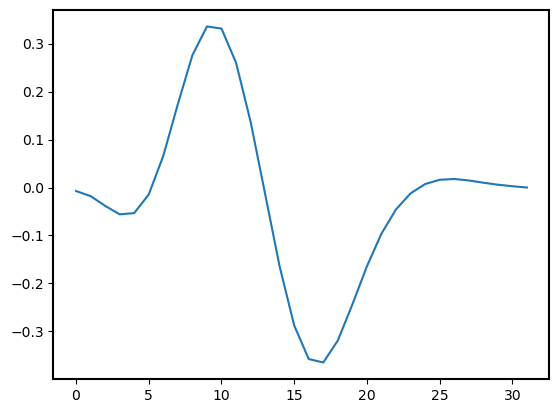

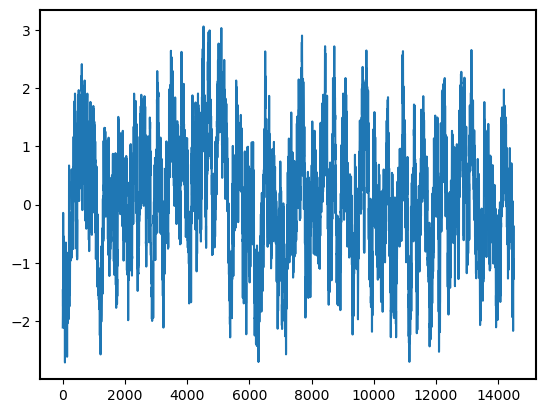

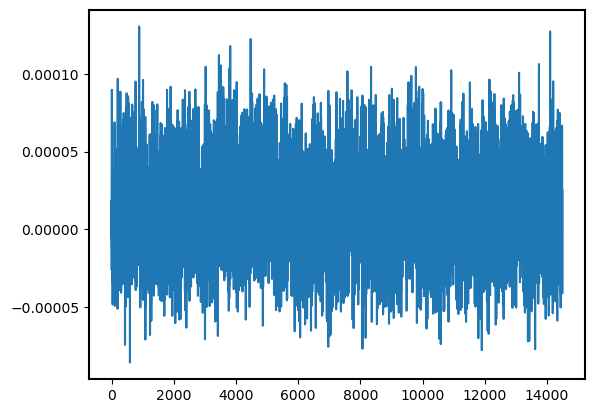

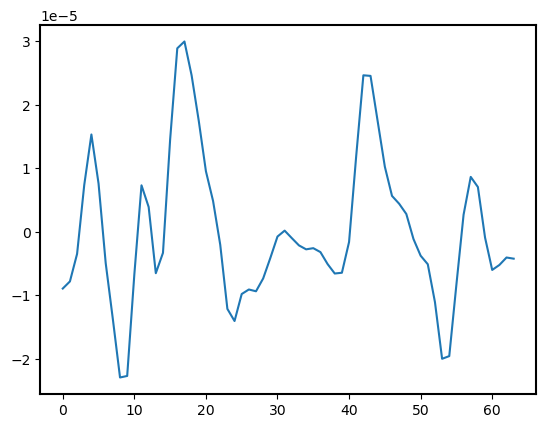

In [877]:
plt.figure()
plt.plot(EOF_u_final)
plt.figure()
plt.plot(PC1_all[0])
plt.figure()
plt.plot(m_fig3[0])
plt.figure()
plt.plot(dmdy[0,0])


In [ ]:
"""
tau^2 ~  Pz / Pm
1. m = γz + m_hat -> m_hat = (m - γz) + residual, 
   which residual = N[0, (m-γz).std()]



"""

In [389]:
fig4_final.shape

(6,)

In [390]:
PC1_all.shape

(6, 14500)

In [391]:
m_fig3.shape

(6, 14500)

In [616]:
num_sample = 500
residual_std = np.zeros(6)

# calculate std each exp
for exp in range(6):
    residual_std[exp] = np.std(m_fig3[exp,:] - fig4_final[exp] * PC1_all[exp,:])
    

In [621]:
np.random.normal(0,scale=residual_std[exp],size=500).shape

(500,)

In [832]:
m_ensemble = np.zeros((6, num_sample, PC1_all.shape[1]))

# generate m ensemble
for exp in range(6):
    for t in range(1,PC1_all.shape[1]):
        m_ensemble[exp,:,0] = m_fig3[exp,0]
        m_ensemble[exp,:,t] =  fig4_final[exp] * m_ensemble[exp,:,t-1] + np.random.normal(0,scale=residual_std[exp],size=500) 
        


In [833]:
print(m_fig3.std())
print(m_ensemble.std())

3.2888128079145537e-05
0.07434264251199908


In [834]:
test  = (m_ensemble[0,100] - m_ensemble[0,100].mean()) / m_ensemble[0,100].std()
test2 = (m_fig3[0,:] - m_fig3[0,:].mean()) / m_fig3[0,:].std()


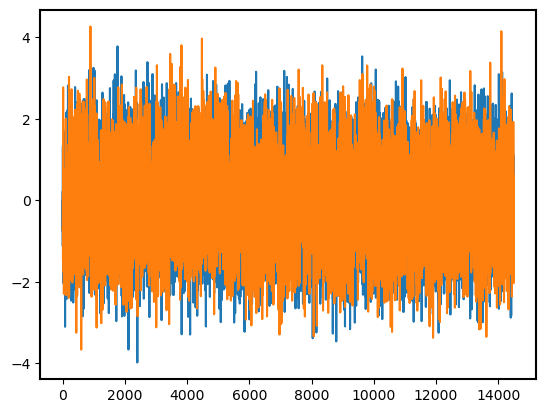

In [835]:
# plt.hist(m_ensemble[0,100])
plt.plot(test)
plt.plot(test2)



In [836]:
PC1_all.shape

(6, 14500)

In [837]:
residual_std_for_z = np.zeros(6)

# calculate std each exp
for exp in range(6):
    residual_std_for_z[exp] = np.std(PC1_all[exp])

In [845]:
PC1_ensemble = np.zeros((6, num_sample, PC1_all.shape[1]))


# generate m ensemble
for exp in range(6):    
    for t in range(PC1_all.shape[1]):
        PC1_ensemble[exp,:,t] = PC1_all[exp,t] + np.random.normal(0,scale=residual_std_for_z[exp],size=500)

(array([ 13.,  26.,  72., 106., 132.,  76.,  54.,  14.,   5.,   2.]),
 array([-4.69762878, -4.07716031, -3.45669184, -2.83622337, -2.21575489,
        -1.59528642, -0.97481795, -0.35434948,  0.26611899,  0.88658746,
         1.50705593]),
 <BarContainer object of 10 artists>)

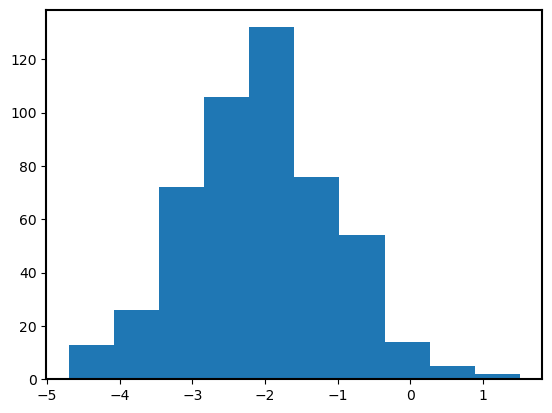

In [846]:
plt.figure()
# plt.plot(PC1_ensemble[0,30,:])
# plt.plot(PC1_all[0,:])
plt.hist(PC1_ensemble[0,:,130])

In [855]:
# Compute cross-spectrum and plot for each experiment
Pz_all_ensemble = np.zeros((6, num_sample, lg), dtype=complex)
Pm_all_ensemble = np.zeros((6, num_sample, lg), dtype=complex)

for exp_idx in range(num_exp):
    for ens in range(num_sample):
        Pz_all_ensemble[exp_idx,ens], Pm_all_ensemble[exp_idx,ens] = compute_fft_cross_spectrum(PC1_ensemble[exp_idx, ens], m_ensemble[exp_idx, ens], lg, overlap)
        

In [856]:
Pz_all_ensemble[0,0,:]

array([0.02832151+0.00000000e+00j, 0.01812445+7.56640692e-20j,
       0.01601865-1.89650591e-19j, ..., 0.01306964+5.43936080e-20j,
       0.01601865+1.89650591e-19j, 0.01812445-7.56640692e-20j])

In [857]:
Pz_all

array([0.703053  +0.00000000e+00j, 0.93490867+9.90805737e-18j,
       0.98950191-1.21187883e-17j, ..., 1.01016299-3.85969565e-18j,
       0.98950191+1.21187883e-17j, 0.93490867-9.90805737e-18j])

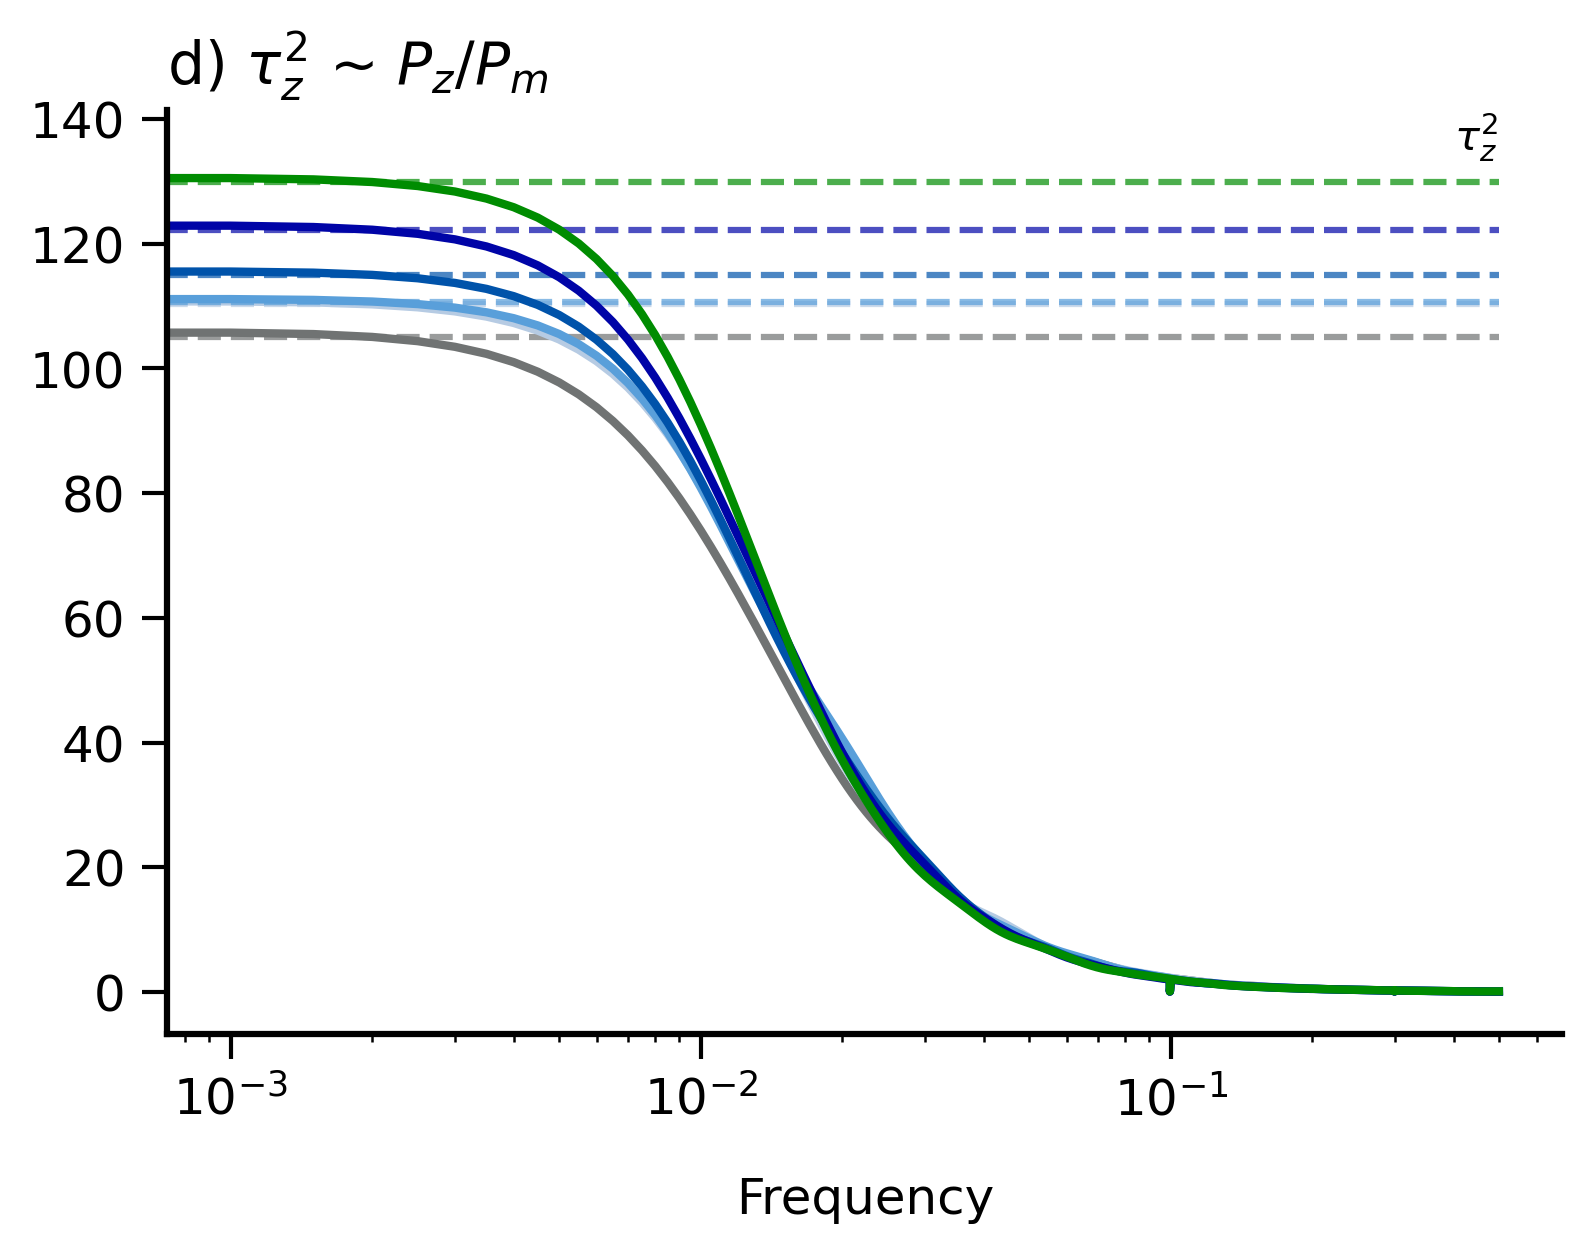

In [858]:
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5


for exp_idx in range(num_exp):
    Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
    freq = np.fft.fftfreq(lg)
    spectrum = Pz_all / Pm_all / (86400**2)

    # Smooth spectrum for better visualization
    tau_smoothed = compute_running_mean(spectrum.real, 5)
    freq_smoothed = compute_running_mean(freq, 5)
    spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
    sorted_idx = np.argsort(freq_smoothed)

    # Plot smoothed spectrum
    plt.plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
               label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

    # Compute and plot tau_z_square
    tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
    plt.hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
                 xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)

plt.title(r"d) $\tau_z^2$ ~ $P_z / P_m$", loc="left", fontsize=14)
plt.xlabel("Frequency", fontsize=12 , labelpad=12)
plt.text(0.4, 135, r"$\tau ^2 _{z}$")
plt.xscale("log")

for i in range(1):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis='x', labelsize=12, pad=4)
    ax.tick_params(axis='y', labelsize=12, pad=4)
    ax.tick_params(direction='out', length=6, width=1)

# plt.tight_layout()

In [859]:
print(PP_all_u[0].std())
print(PP_all_u[0].mean())


9.294094898648103
0.69530750928742


In [860]:
print(Pz_all_ensemble[0,0].std())
print(Pz_all_ensemble[0,0].mean())


0.0014734054115162363
(0.0003793160823448558-2.407412430484045e-38j)


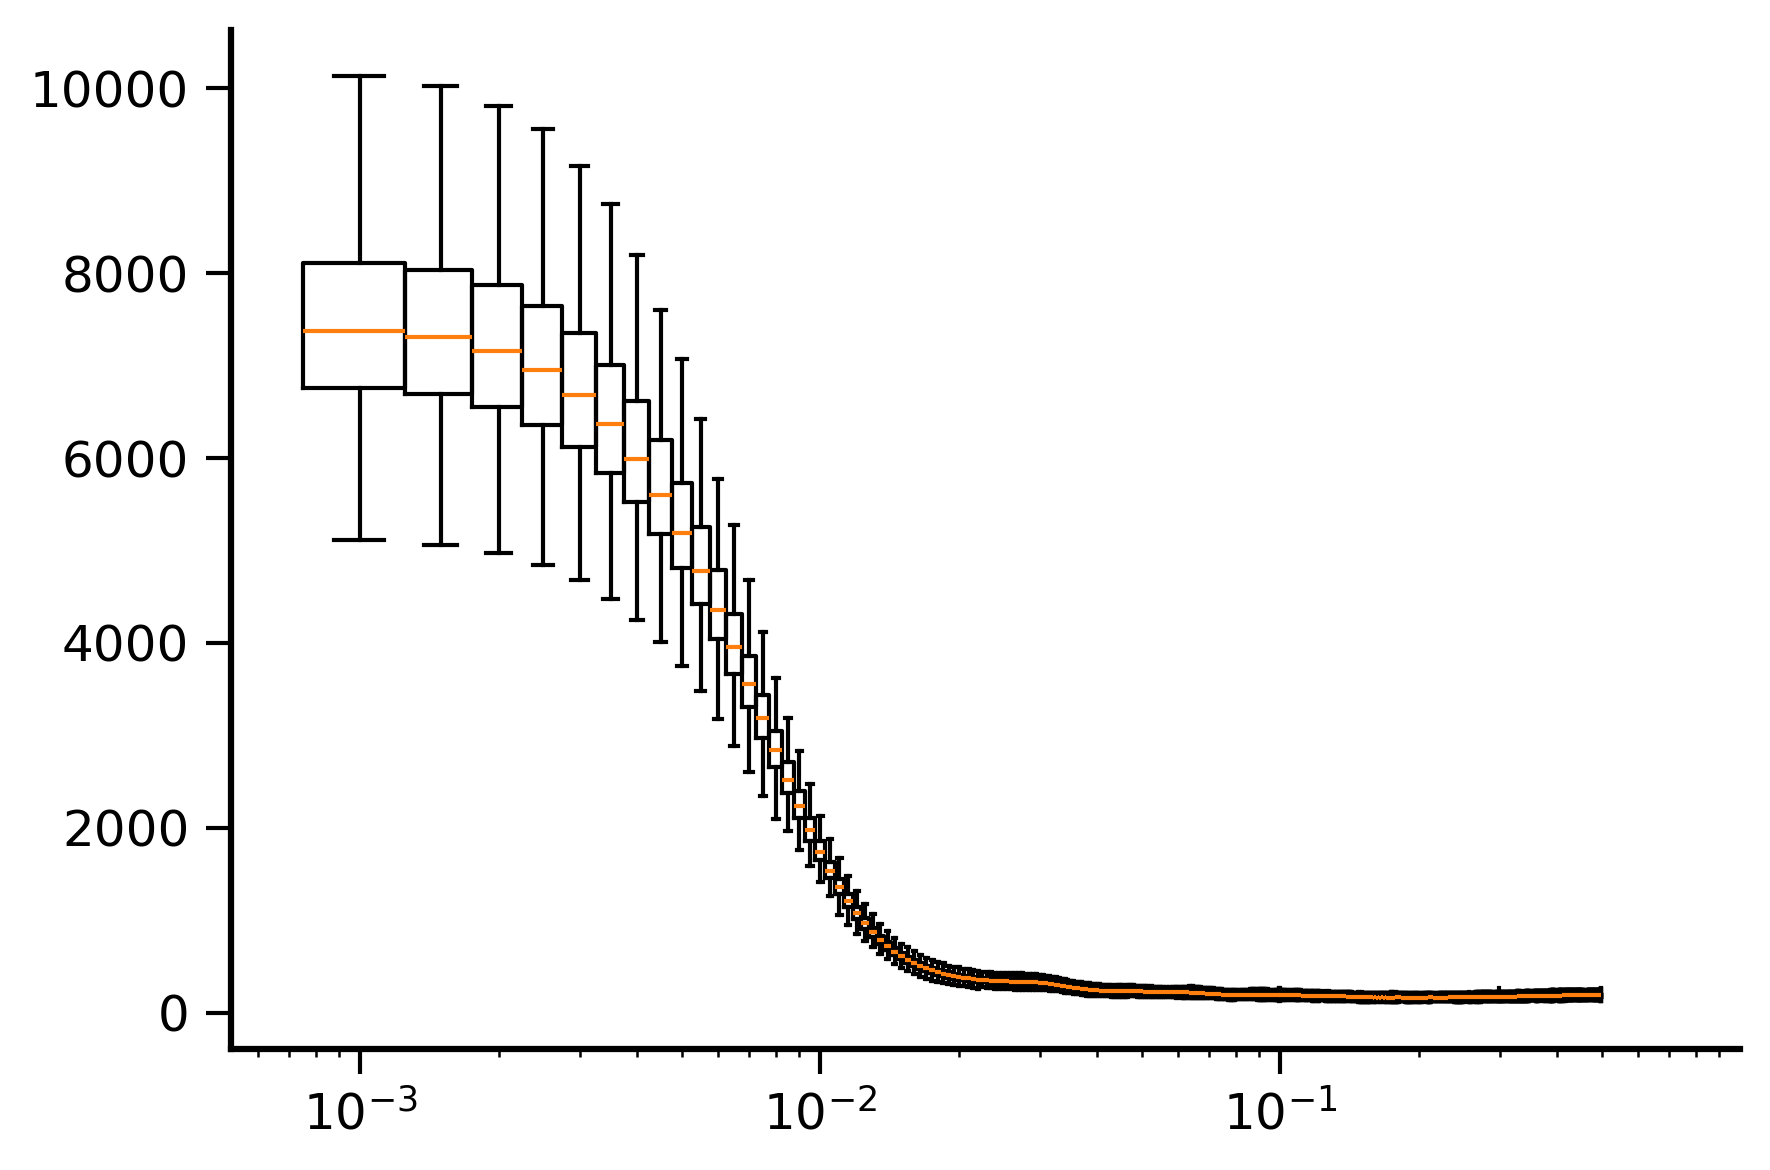

In [870]:
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5

# Pz_all_ensemble
spectrum_ensemble = np.zeros((num_exp, num_sample, lg), dtype=complex)
spectrum_gaussian_ensemble = np.zeros((num_exp, num_sample, lg-4))
sorted_idx = np.argsort(freq_smoothed)



for exp_idx in range(0,1):
    for ens in range(num_sample):
        # Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
        # Pz_all_ensemble[exp_idx]
        freq = np.fft.fftfreq(lg)
        spectrum_ensemble[exp_idx, ens,:] = Pz_all_ensemble[exp_idx,ens] / Pm_all_ensemble[exp_idx,ens] / (86400**2)
    
        # Smooth spectrum for better visualization
        tau_smoothed = compute_running_mean(spectrum_ensemble[exp_idx, ens,:].real, 5)
        freq_smoothed = compute_running_mean(freq, 5)
        
        spectrum_gaussian_ensemble[exp_idx, ens,:] = gaussian_filter1d(tau_smoothed, sigma=8)
        sorted_idx = np.argsort(freq_smoothed)
    
    # Plot smoothed spectrum
    # plt.boxplot(freq_smoothed[sorted_idx], spectrum_ensemble[:,sorted_idx].T)
    # plt.boxplot(spectrum_ensemble[:, sorted_idx], positions=freq_smoothed[sorted_idx])
    # for i in range(1996):
    # plt.boxplot(spectrum_gaussian_ensemble[:,sorted_idx], positions=freq_smoothed[sorted_idx],sym='')  # Without positions


               # label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)
    
        # # Compute and plot tau_z_square
        # tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
        # plt.hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
        #              xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)
plt.boxplot(spectrum_gaussian_ensemble[0, :,sorted_idx[995:]].T, positions=freq_smoothed[sorted_idx][995:], widths=0.0005, sym='')


# for exp_idx in range(1):
#     Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
#     freq = np.fft.fftfreq(lg)
#     spectrum = Pz_all / Pm_all / (86400**2)

#     # Smooth spectrum for better visualization
#     tau_smoothed = compute_running_mean(spectrum.real, 5)
#     freq_smoothed = compute_running_mean(freq, 5)
#     spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
#     sorted_idx = np.argsort(freq_smoothed)

#     # Plot smoothed spectrum
#     plt.plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
#                label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

#     # Compute and plot tau_z_square
#     tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
#     plt.hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
#                  xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)


# plt.title(r"d) $\tau_z^2$ ~ $P_z / P_m$", loc="left", fontsize=14)
# plt.xlabel("Frequency", fontsize=12 , labelpad=12)
# plt.text(0.4, 135, r"$\tau ^2 _{z}$")
plt.xscale("log")

for i in range(1):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis='x', labelsize=12, pad=4)
    ax.tick_params(axis='y', labelsize=12, pad=4)
    ax.tick_params(direction='out', length=6, width=1)

plt.tight_layout()

In [867]:
freq_smoothed[sorted_idx][995:]

array([-0.0025, -0.002 , -0.0015, ...,  0.4975,  0.498 ,  0.4985])

In [778]:
spectrum_gaussian_ensemble.shape

(6, 500, 1996)

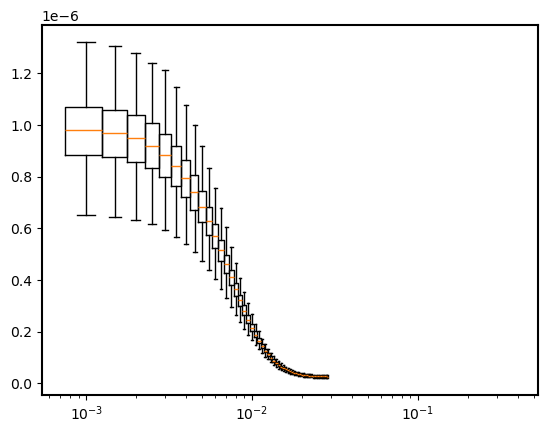

In [779]:
plt.figure()
# for i in range(10):
# plt.boxplot(spectrum_gaussian_ensemble[:,sorted_idx], positions=freq_smoothed[sorted_idx],sym='')  # Without positions

plt.boxplot(spectrum_gaussian_ensemble[0, :,sorted_idx[995:1054]].T, positions=freq_smoothed[sorted_idx][995:1054], widths=0.0005, sym='')
plt.xscale("log")

In [643]:
spectrum_gaussian_ensemble[:,sorted_idx][0].shape

(1996,)

In [478]:
print(f"spectrum_ensemble[:, sorted_idx].T shape: {spectrum_ensemble[:, sorted_idx].T.shape}")
print(f"freq_smoothed[sorted_idx] shape: {freq_smoothed[sorted_idx].shape}")


spectrum_ensemble[:, sorted_idx].T shape: (1996, 500)
freq_smoothed[sorted_idx] shape: (1996,)


In [476]:
spectrum_ensemble.shape

(500, 2000)

In [477]:
freq_smoothed.shape

(1996,)

In [480]:
sorted_idx.shape

(1996,)

array([ 0.    ,  0.0005,  0.001 , ..., -0.0015, -0.001 , -0.0005])